# 📊 Exploratory Data Analysis
## Student Performance Predictor
**Course:** Soft Computing  
**Models:** Logistic Regression (Pass/Fail) + Linear Regression (Score Prediction)

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, r2_score, mean_absolute_error,
    mean_squared_error, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PASS_COLOR = '#2ECC71'
FAIL_COLOR = '#E74C3C'
BLUE       = '#2980B9'

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('D:/VIT/Soft Computing/data/student_data.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (250, 6)


,study_hours,attendance,previous_marks,assignments_completed,final_score,pass
0,4.37,57.67,75.38,2,73.64,1
1,9.56,63.11,64.85,5,86.02,1
2,7.59,91.07,50.12,5,73.76,1
3,6.39,59.02,82.90,2,71.18,1
4,2.40,50.17,74.51,6,53.32,1
5,2.40,73.41,40.57,2,46.50,0
6,1.52,96.17,89.21,7,67.41,1
7,8.80,81.76,83.46,9,100.00,1
8,6.41,74.20,91.74,3,92.21,1
9,7.37,45.83,77.17,0,71.72,1


In [3]:
df.describe().round(2)

,study_hours,attendance,previous_marks,assignments_completed,final_score,pass
count,250.00,250.00,250.00,250.00,250.00,250.00
mean,5.41,70.40,61.64,4.82,68.24,0.88
std,2.68,18.02,18.55,3.14,14.58,0.33
min,1.05,40.65,30.95,0.00,27.27,0.00
25%,3.08,56.68,45.47,2.00,57.73,1.00
50%,5.52,71.53,60.73,5.00,69.53,1.00
75%,7.78,85.42,78.38,7.00,78.21,1.00
max,9.88,99.58,94.98,10.00,100.00,1.00


In [4]:
print('Missing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)
print('\nPass/Fail counts:')
print(df['pass'].value_counts().rename({1:'Pass', 0:'Fail'}))

Missing values:
study_hours              0
attendance               0
previous_marks           0
assignments_completed    0
final_score              0
pass                     0
dtype: int64

Data types:
study_hours              float64
attendance               float64
previous_marks           float64
assignments_completed      int64
final_score              float64
pass                       int64
dtype: object

Pass/Fail counts:
pass
Pass    220
Fail     30
Name: count, dtype: int64


## 2. Train/Test Split & Model Training

In [5]:
FEATURES = ['study_hours','attendance','previous_marks','assignments_completed']
X     = df[FEATURES]
y_cls = df['pass']
y_reg = df['final_score']

X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=42
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_sc, y_cls_train)

reg = LinearRegression()
reg.fit(X_train_sc, y_reg_train)

y_pred_cls   = clf.predict(X_test_sc)
y_prob       = clf.predict_proba(X_test_sc)[:, 1]
y_pred_score = reg.predict(X_test_sc)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Classification Accuracy : {accuracy_score(y_cls_test, y_pred_cls)*100:.2f}%')
print(f'Regression R2           : {r2_score(y_reg_test, y_pred_score):.4f}')

Train size: 200 | Test size: 50
Classification Accuracy : 96.00%
Regression R2           : 0.8945


## 3. Score Distribution & Pass/Fail Split

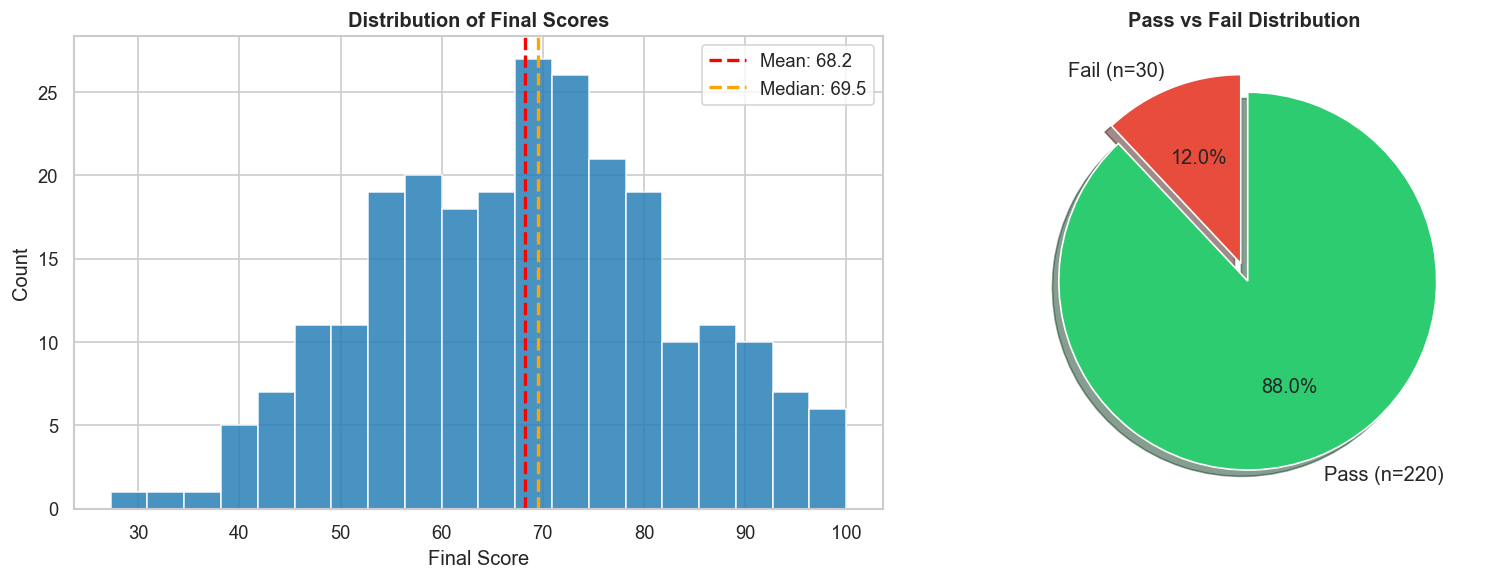

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['final_score'], bins=20, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['final_score'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['final_score'].mean():.1f}")
axes[0].axvline(df['final_score'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median: {df['final_score'].median():.1f}")
axes[0].set_title('Distribution of Final Scores', fontweight='bold')
axes[0].set_xlabel('Final Score')
axes[0].set_ylabel('Count')
axes[0].legend()

counts = df['pass'].value_counts().sort_index()
labels = [f'Fail (n={counts.get(0,0)})', f'Pass (n={counts.get(1,0)})']
axes[1].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=[FAIL_COLOR, PASS_COLOR], startangle=90,
            explode=(0.05,0.05), shadow=True, textprops={'fontsize':12})
axes[1].set_title('Pass vs Fail Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('D:/VIT/Soft Computing/reports/01_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Study Hours vs Final Score

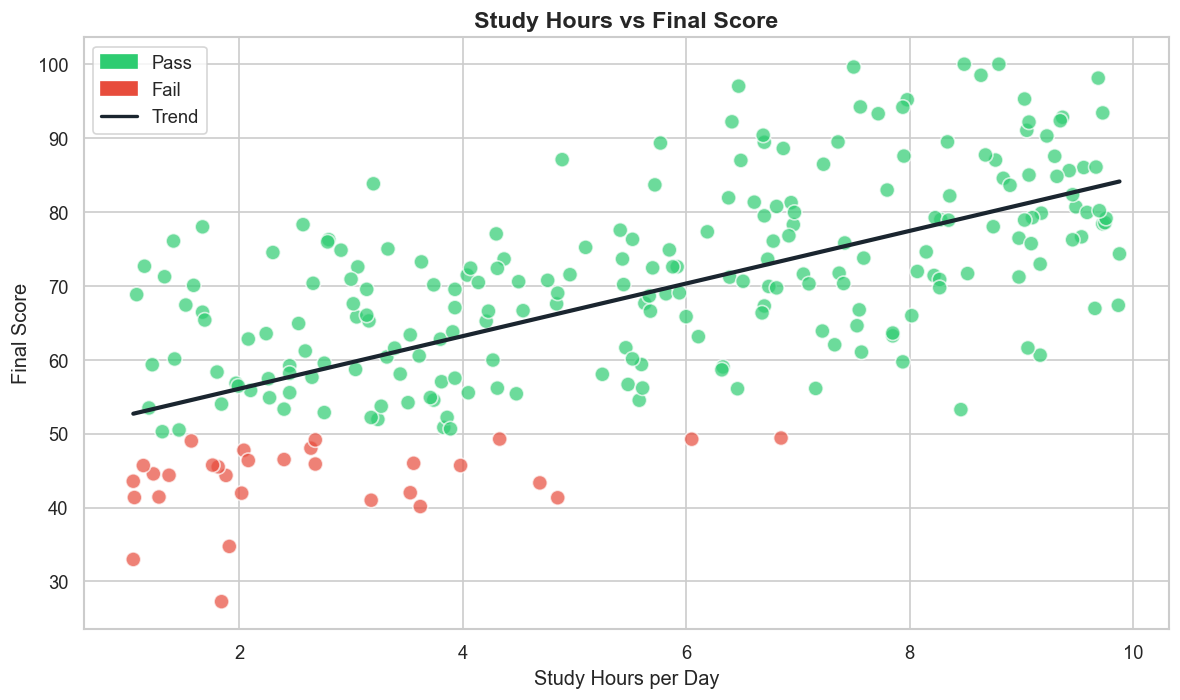

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = df['pass'].map({1: PASS_COLOR, 0: FAIL_COLOR})
ax.scatter(df['study_hours'], df['final_score'], c=colors, alpha=0.7, edgecolors='white', s=80)

m, b = np.polyfit(df['study_hours'], df['final_score'], 1)
x_line = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 100)
ax.plot(x_line, m*x_line + b, color='#1A252F', linewidth=2.5,
        label=f'Trend (slope={m:.2f})')

pass_patch = mpatches.Patch(color=PASS_COLOR, label='Pass')
fail_patch = mpatches.Patch(color=FAIL_COLOR, label='Fail')
ax.legend(handles=[pass_patch, fail_patch,
                   plt.Line2D([0],[0], color='#1A252F', linewidth=2, label='Trend')])
ax.set_xlabel('Study Hours per Day', fontsize=12)
ax.set_ylabel('Final Score', fontsize=12)
ax.set_title('Study Hours vs Final Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/VIT/Soft Computing/reports/02_study_hours_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

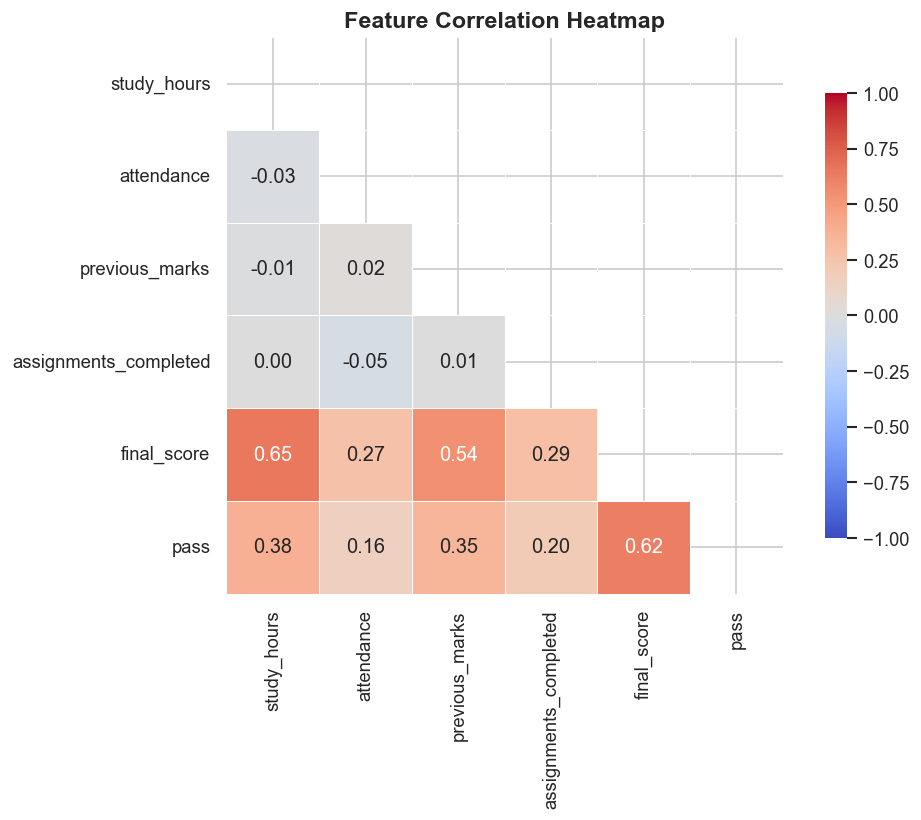

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/VIT/Soft Computing/reports/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance (Linear Regression |Coefficients|)

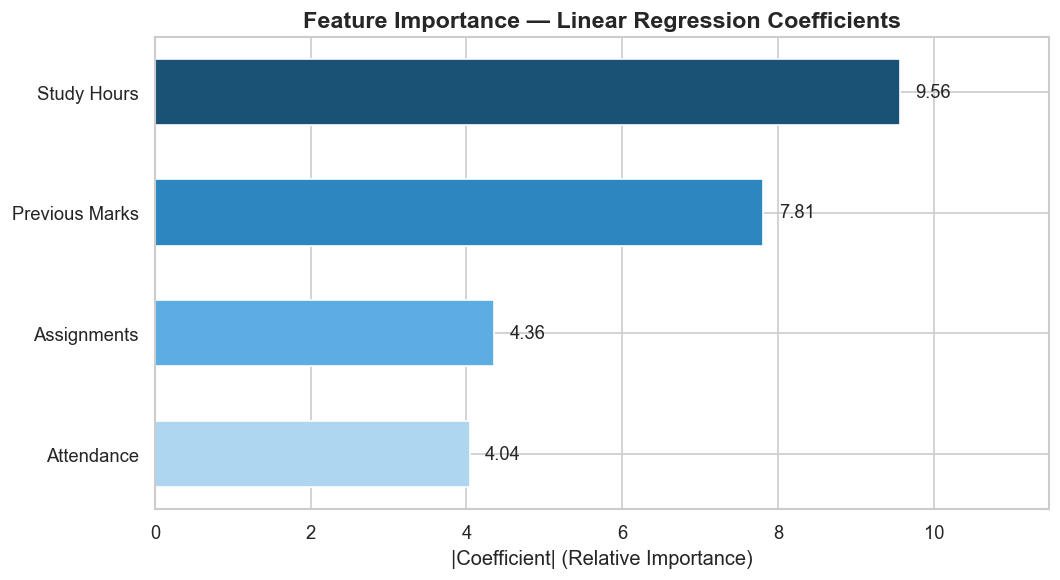

Importances:
  Study Hours         : 9.5639
  Previous Marks      : 7.8139
  Assignments         : 4.3573
  Attendance          : 4.0410


In [9]:
feat_labels = ['Study Hours','Attendance','Previous Marks','Assignments']
importances = pd.Series(np.abs(reg.coef_), index=feat_labels).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importances.index, importances.values,
               color=['#AED6F1','#5DADE2','#2E86C1','#1A5276'],
               edgecolor='white', height=0.55)
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=11)
ax.set_xlabel('|Coefficient| (Relative Importance)')
ax.set_title('Feature Importance — Linear Regression Coefficients', fontsize=14, fontweight='bold')
ax.set_xlim(0, importances.max()*1.2)
plt.tight_layout()
plt.savefig('D:/VIT/Soft Computing/reports/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Importances:')
for feat, val in importances.sort_values(ascending=False).items():
    print(f'  {feat:20s}: {val:.4f}')

## 7. Box Plots by Pass/Fail Outcome

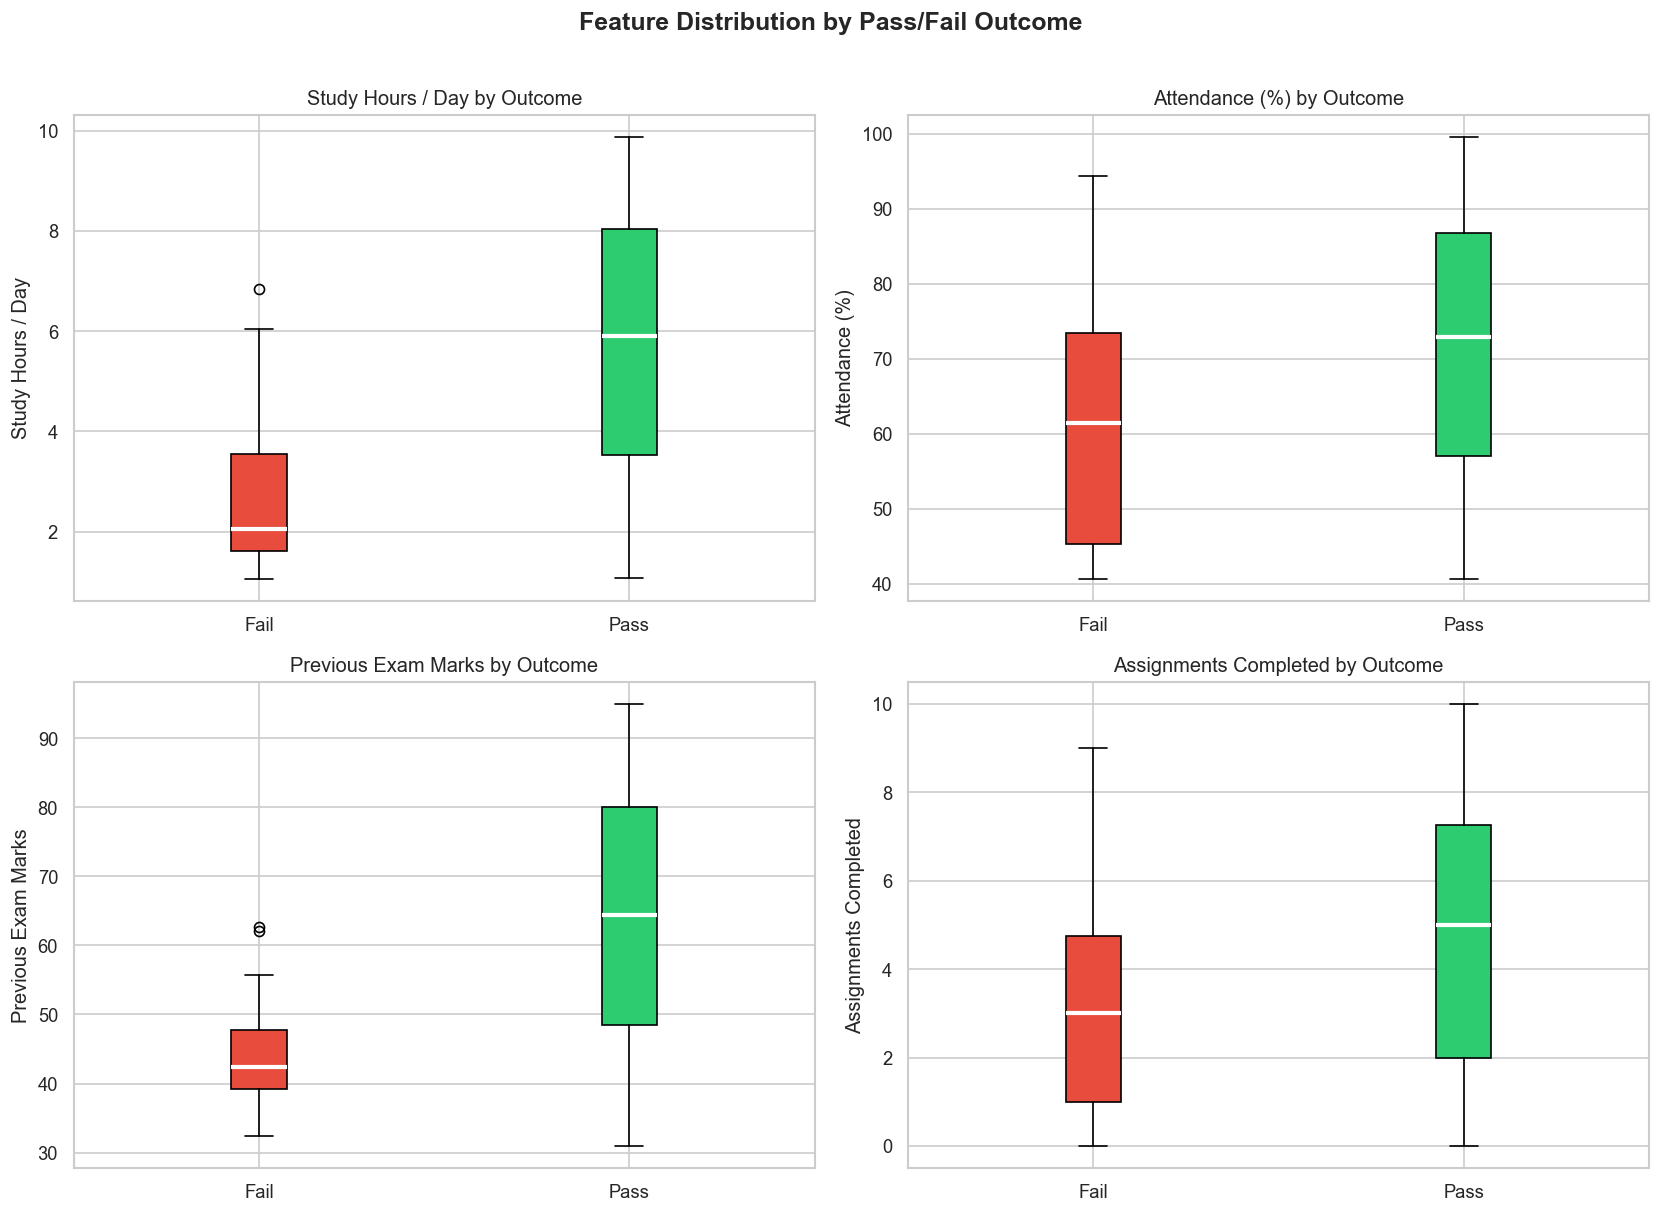

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
feat_map = {'study_hours':'Study Hours / Day',
            'attendance':'Attendance (%)',
            'previous_marks':'Previous Exam Marks',
            'assignments_completed':'Assignments Completed'}
for ax, (col, label) in zip(axes.flatten(), feat_map.items()):
    data_fail = df[df['pass']==0][col]
    data_pass = df[df['pass']==1][col]
    bp = ax.boxplot([data_fail, data_pass], labels=['Fail','Pass'],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2.5))
    bp['boxes'][0].set_facecolor(FAIL_COLOR)
    bp['boxes'][1].set_facecolor(PASS_COLOR)
    ax.set_title(f'{label} by Outcome')
    ax.set_ylabel(label)
plt.suptitle('Feature Distribution by Pass/Fail Outcome', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('D:/VIT/Soft Computing/reports/05_boxplots_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Confusion Matrix

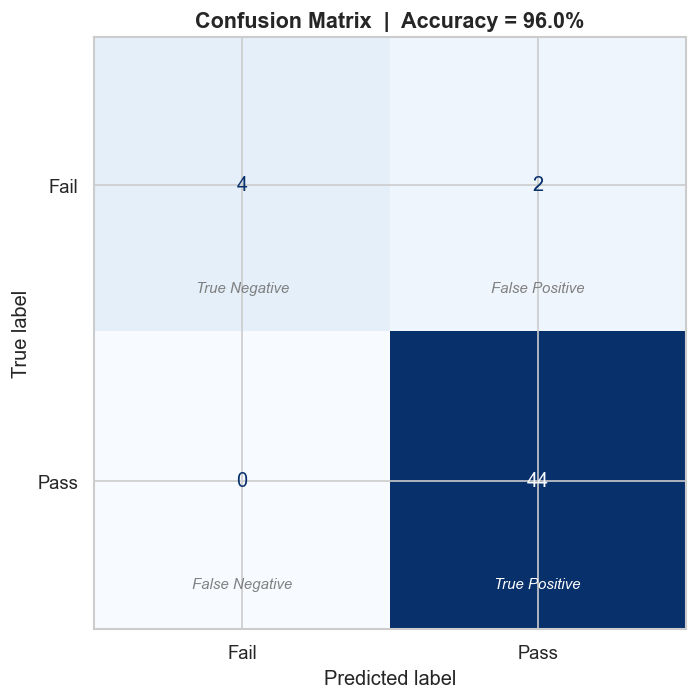

              precision    recall  f1-score   support

        Fail       1.00      0.67      0.80         6
        Pass       0.96      1.00      0.98        44

    accuracy                           0.96        50
   macro avg       0.98      0.83      0.89        50
weighted avg       0.96      0.96      0.96        50



In [11]:
cm  = confusion_matrix(y_cls_test, y_pred_cls)
acc = accuracy_score(y_cls_test, y_pred_cls)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail','Pass'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')

cell_labels = {(0,0):'True Negative', (0,1):'False Positive',
               (1,0):'False Negative', (1,1):'True Positive'}
for (r,c), lbl in cell_labels.items():
    ax.text(c, r+0.35, lbl, ha='center', va='center', fontsize=9,
            color='white' if cm[r,c] > cm.max()/2 else 'gray', style='italic')

ax.set_title(f'Confusion Matrix  |  Accuracy = {acc*100:.1f}%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/VIT/Soft Computing/reports/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_cls_test, y_pred_cls, target_names=['Fail','Pass']))

## 9. ROC Curve (AUC)

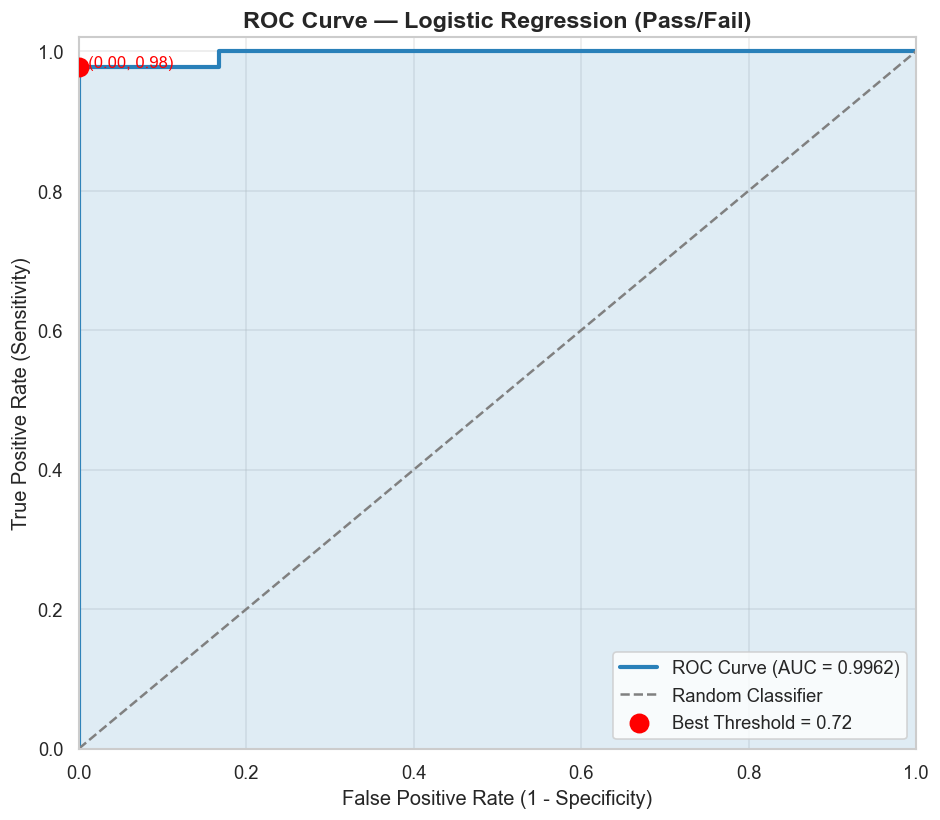

ROC AUC Score: 0.9962


In [12]:
fpr, tpr, thresholds = roc_curve(y_cls_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color=BLUE, lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.15, color=BLUE)

best_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[best_idx], tpr[best_idx], s=120, color='red', zorder=5,
           label=f'Best Threshold = {thresholds[best_idx]:.2f}')
ax.annotate(f'  ({fpr[best_idx]:.2f}, {tpr[best_idx]:.2f})',
            (fpr[best_idx], tpr[best_idx]), fontsize=10, color='red')

ax.set_xlim([0,1])
ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve — Logistic Regression (Pass/Fail)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('D:/VIT/Soft Computing/reports/07_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC AUC Score: {roc_auc:.4f}')

## 10. Predicted vs Actual Score & Residual Plot

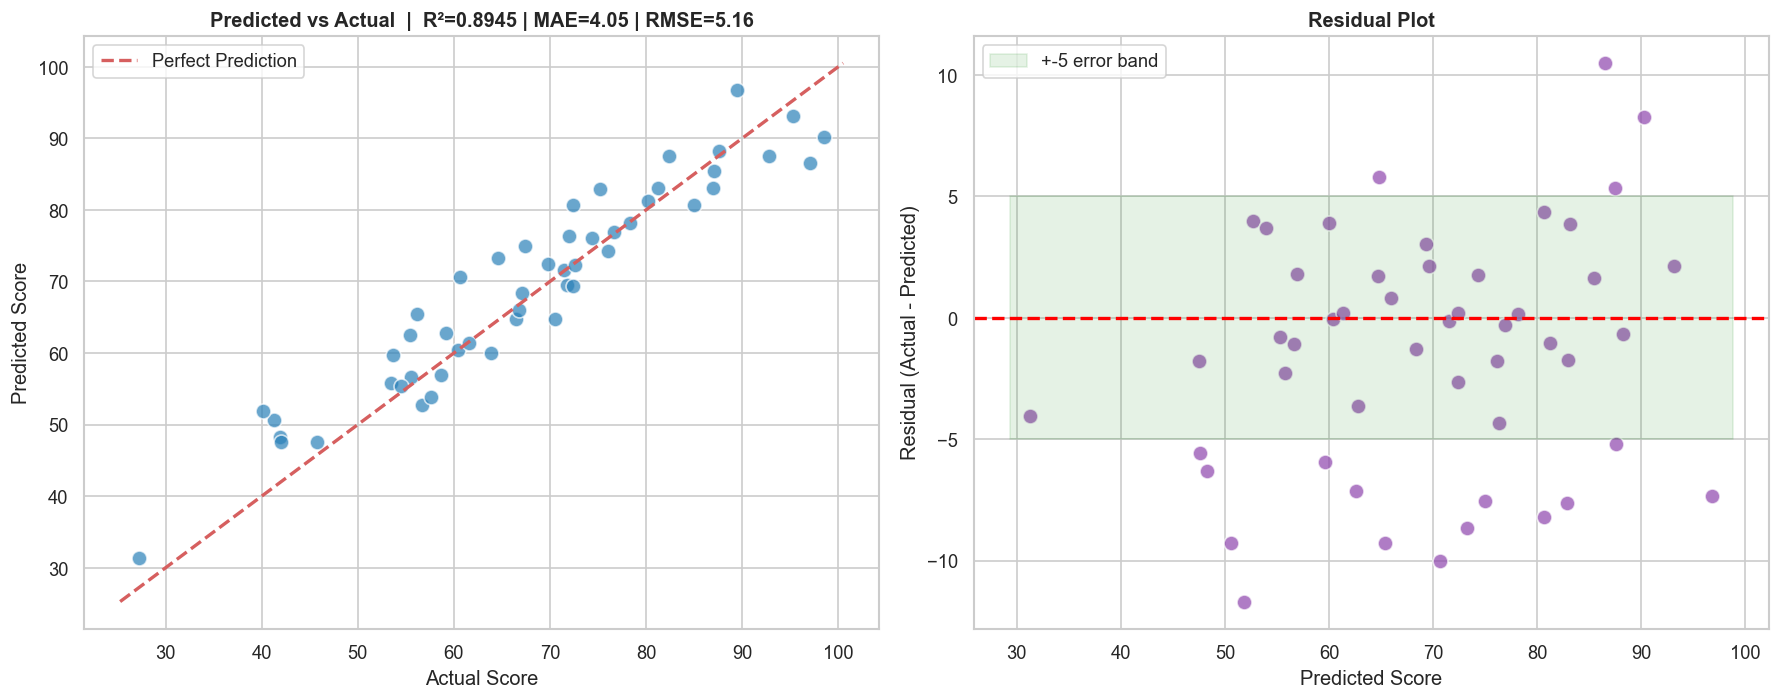

In [13]:
r2   = r2_score(y_reg_test, y_pred_score)
mae  = mean_absolute_error(y_reg_test, y_pred_score)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_score))
residuals = y_reg_test.values - y_pred_score

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_reg_test, y_pred_score, color=BLUE, alpha=0.7, edgecolors='white', s=80)
mn = min(y_reg_test.min(), y_pred_score.min()) - 2
mx = max(y_reg_test.max(), y_pred_score.max()) + 2
axes[0].plot([mn,mx],[mn,mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Predicted vs Actual  |  R²={r2:.4f} | MAE={mae:.2f} | RMSE={rmse:.2f}', fontweight='bold')
axes[0].legend()

axes[1].scatter(y_pred_score, residuals, color='#8E44AD', alpha=0.7, edgecolors='white', s=80)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].fill_between([y_pred_score.min()-2, y_pred_score.max()+2],
                     [-5,-5],[5,5], alpha=0.1, color='green', label='+-5 error band')
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('D:/VIT/Soft Computing/reports/08_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Learning Curves

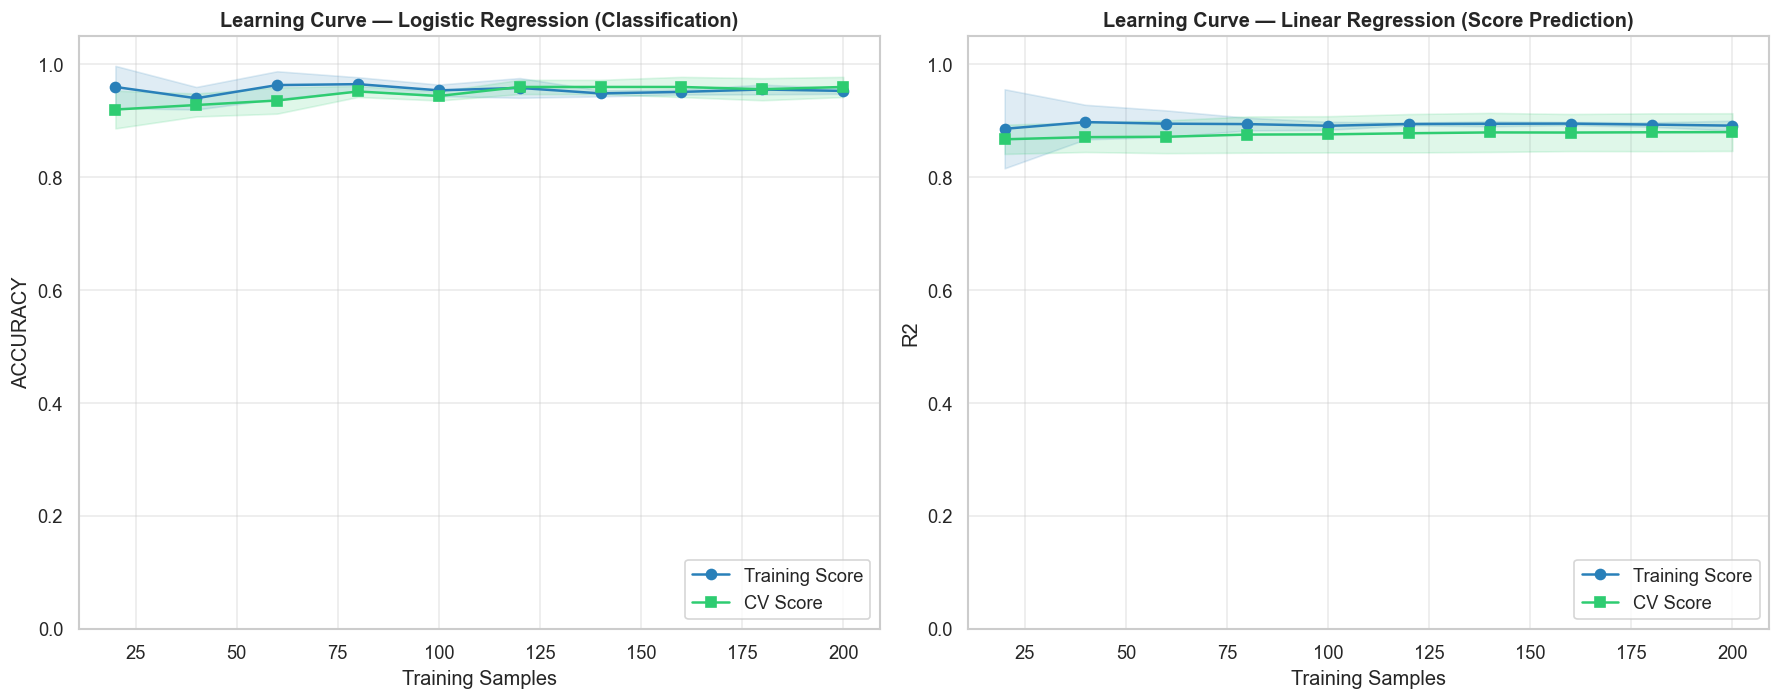

In [14]:
X_all_sc = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

configs = [
    (LogisticRegression(max_iter=1000, random_state=42), y_cls, 'accuracy', 'Logistic Regression (Classification)'),
    (LinearRegression(), y_reg, 'r2', 'Linear Regression (Score Prediction)')
]

for ax, (model, y_target, scorer, title) in zip(axes, configs):
    train_sizes, train_sc, val_sc = learning_curve(
        model, X_all_sc, y_target, cv=5, scoring=scorer,
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42, shuffle=True
    )
    ax.plot(train_sizes, train_sc.mean(axis=1), 'o-', color=BLUE, label='Training Score')
    ax.fill_between(train_sizes, train_sc.mean(1)-train_sc.std(1),
                                 train_sc.mean(1)+train_sc.std(1), alpha=0.15, color=BLUE)
    ax.plot(train_sizes, val_sc.mean(axis=1), 's-', color=PASS_COLOR, label='CV Score')
    ax.fill_between(train_sizes, val_sc.mean(1)-val_sc.std(1),
                                 val_sc.mean(1)+val_sc.std(1), alpha=0.15, color=PASS_COLOR)
    ax.set_xlabel('Training Samples')
    ax.set_ylabel(scorer.upper())
    ax.set_title(f'Learning Curve — {title}', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.4)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('D:/VIT/Soft Computing/reports/09_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Final Model Summary

In [15]:
print('='*55)
print('  MODEL PERFORMANCE SUMMARY')
print('='*55)
print(f'  Classification Accuracy : {accuracy_score(y_cls_test, y_pred_cls)*100:.2f}%')
print(f'  ROC AUC Score           : {roc_auc:.4f}')
print(f'  Regression R2 Score     : {r2:.4f}')
print(f'  Mean Absolute Error     : {mae:.4f}')
print(f'  RMSE                    : {rmse:.4f}')
print('='*55)
print('\nGroup Stats by Pass/Fail:')
print(df.groupby('pass')[FEATURES + ['final_score']].mean().round(2))

  MODEL PERFORMANCE SUMMARY
  Classification Accuracy : 96.00%
  ROC AUC Score           : 0.9962
  Regression R2 Score     : 0.8945
  Mean Absolute Error     : 4.0519
  RMSE                    : 5.1576

Group Stats by Pass/Fail:
      study_hours  attendance  previous_marks  assignments_completed  \
pass                                                                   
0            2.67       62.62           44.26                   3.10   
1            5.79       71.46           64.02                   5.05   

      final_score  
pass               
0           43.79  
1           71.57  
